In [22]:
import pandas as pd
import numpy as np

# Criação de um dataset simulado com anomalias propositais
dados_brutos = {
    "cliente_id": [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    "idade": [25, 32, -4, 45, np.nan, 29, 38, 999, 52, 22],
    "renda_mensal": [2500.0, 4200.0, 3100.0, np.nan, 5800.0, 3900.0, 15000000.0, 6100.0, 8500.0, 2100.0],
    "escolaridade": ["Superior", "Médio", "Superior", "Fundamental", "Superior", "Médio", "Superior", "Médio", "Pós-Graduação", "Médio"],
    "cidade": ["Campinas", "São Paulo", "Santos", "São Paulo", "Campinas", np.nan, "São Paulo", "Santos", "Campinas", "São Paulo"],
    "inadimplente": [0, 0, 1, 1, 0, 0, 1, 0, 1, 0]
}

df = pd.DataFrame(dados_brutos)
print("--- Primeiras Linhas do DataFrame Bruto ---")
print(df.head())

--- Primeiras Linhas do DataFrame Bruto ---
   cliente_id  idade  renda_mensal escolaridade     cidade  inadimplente
0         101  25.00       2500.00     Superior   Campinas             0
1         102  32.00       4200.00        Médio  São Paulo             0
2         103  -4.00       3100.00     Superior     Santos             1
3         104  45.00           NaN  Fundamental  São Paulo             1
4         105    NaN       5800.00     Superior   Campinas             0


In [23]:
print("Informações Estruturais do DataFrame")
df.info()

Informações Estruturais do DataFrame
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cliente_id    10 non-null     int64  
 1   idade         9 non-null      float64
 2   renda_mensal  9 non-null      float64
 3   escolaridade  10 non-null     str    
 4   cidade        9 non-null      str    
 5   inadimplente  10 non-null     int64  
dtypes: float64(2), int64(2), str(2)
memory usage: 612.0 bytes


In [24]:
print("Resumo Estatístico das Variáveis Numéricas")
pd.set_option("display.float_format", lambda x: f"{x:.2f}")
df.describe()

Resumo Estatístico das Variáveis Numéricas


,cliente_id,idade,renda_mensal,inadimplente
count,10.00,9.00,9.00,10.00
mean,105.50,137.56,1670688.89,0.40
std,3.03,323.43,4998492.07,0.52
min,101.00,-4.00,2100.00,0.00
25%,103.25,25.00,3100.00,0.00
50%,105.50,32.00,4200.00,0.00
75%,107.75,45.00,6100.00,1.00
max,110.00,999.00,15000000.00,1.00


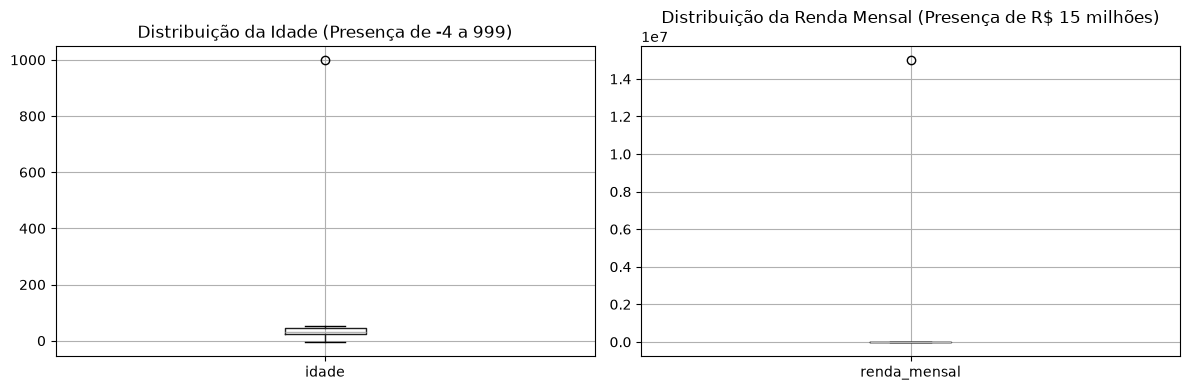

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,2, figsize=(12,4))

df.boxplot(column=["idade"], ax=axes[0])
axes[0].set_title("Distribuição da Idade (Presença de -4 a 999)")

df.boxplot(column=["renda_mensal"], ax=axes[1])
axes[1].set_title("Distribuição da Renda Mensal (Presença de R$ 15 milhões)")

plt.tight_layout()
plt.show()

In [26]:
nulos_por_coluna = df.isna().sum()
print("Quantidade de Nulos por Coluna")
print(nulos_por_coluna)

Quantidade de Nulos por Coluna
cliente_id      0
idade           1
renda_mensal    1
escolaridade    0
cidade          1
inadimplente    0
dtype: int64


In [27]:
df_limpo = df.copy()

# 1. Váriavel (cidade) pela moda
moda_cidade = df_limpo["cidade"].mode()[0]
df_limpo["cidade"] = df_limpo["cidade"].fillna(moda_cidade)

# 2. Rernda Mensal pela mediana dos valores
mediana_renda = df_limpo.loc[df_limpo["renda_mensal"] < 1000000, "renda_mensal"].median()
df_limpo["renda_mensal"] = df_limpo["renda_mensal"].fillna(mediana_renda)

# 3. Correção de idades inválidas/nulas pela mediana (18 a 120anos)
filtro_idade_valida = (df_limpo["idade"] >= 18) & (df_limpo["idade"] <= 120)
mediana_idade = df_limpo.loc[filtro_idade_valida, "idade"].median()
df_limpo.loc[~filtro_idade_valida, "idade"] = mediana_idade

# 4. Remoção de renda absurda ( que ultrapassa R$ 1.000.000 neste contexto)
df_limpo = df_limpo[df_limpo["renda_mensal"] < 1000000].reset_index(drop=True)

print("DataFrame após tratamento de Nulos")
print(df_limpo[["cliente_id", "idade", "renda_mensal", "cidade"]])

DataFrame após tratamento de Nulos
   cliente_id  idade  renda_mensal     cidade
0         101  25.00       2500.00   Campinas
1         102  32.00       4200.00  São Paulo
2         103  32.00       3100.00     Santos
3         104  45.00       4050.00  São Paulo
4         105  32.00       5800.00   Campinas
5         106  29.00       3900.00  São Paulo
6         108  32.00       6100.00     Santos
7         109  52.00       8500.00   Campinas
8         110  22.00       2100.00  São Paulo


In [28]:
# Aplicação do One-Hot Enconding na cidade
df_processado = pd.get_dummies(df_limpo, columns=["cidade"], dtype=int)

# Codificação Ordinal para escolaridade
mapeamento_escolaridade = {
    "Fundamental" : 0,
    "Médio": 1,
    "Superior": 2,
    "Pós-Graduação": 3
}
df_processado["escolaridade"] = df_processado["escolaridade"].map(mapeamento_escolaridade)

# Remover cliente_id 
df_processado = df_processado.drop(columns=["cliente_id"])

print("Matriz Processada Pronta para Escalonamento")
print(df_processado.head())

Matriz Processada Pronta para Escalonamento
   idade  renda_mensal  escolaridade  inadimplente  cidade_Campinas  \
0  25.00       2500.00             2             0                1   
1  32.00       4200.00             1             0                0   
2  32.00       3100.00             2             1                0   
3  45.00       4050.00             0             1                0   
4  32.00       5800.00             2             0                1   

   cidade_Santos  cidade_São Paulo  
0              0                 0  
1              0                 1  
2              1                 0  
3              0                 1  
4              0                 0  


In [29]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Base de treino  
# X1 = Anos de Relacionamento ( Escala de 1.0 a 10.0 anos)
# X2 = Renda Mensal Declarada ( Escala de R$ 2.800 a R$ 16.000)
X_bruto = np.array([
    [1.0, 3000.0],
    [1.5, 2980.0],
    [2.0, 3020.0],
    [8.0, 3500.0],
    [8.5, 3600.0],
    [9.0, 3400.0],
    [1.0, 15000.0],
    [2.0, 16000.0]
])

# Classe : 0 (Crédito Negado), 1 (Crédito Aprovado)
y = np.array([0, 0, 0, 1, 1, 1, 1 , 1])

# Novo cliente : 8.5 anos de conta e R$ 3.010 de renda (Deveria ser Aprovado = 1)
novo_cliente = np.array([[8.5, 3010.0]])

In [30]:
knn_sem_escala = KNeighborsClassifier(n_neighbors=3)
knn_sem_escala.fit(X_bruto, y)

pred_sem_escala = knn_sem_escala.predict(novo_cliente)
distancias_sem_escala, indices_sem_escala = knn_sem_escala.kneighbors(novo_cliente)

print("=" * 60)
print("                    KNN SEM ESACALONAMENTO (DADOS BRUTOS)                         ")
print("=" * 60)
print(f"Novo Cliente: {novo_cliente[0]} (8.5 anos e R$ 3.010 de renda)")
print(f"Classe Predita: {pred_sem_escala[0]} (Esperado 1)")
print(f"Vizinhos selecionados (índices): {indices_sem_escala[0]}")
print(f"Distâncias calculadas: {distancias_sem_escala[0]}")

                    KNN SEM ESACALONAMENTO (DADOS BRUTOS)                         
Novo Cliente: [   8.5 3010. ] (8.5 anos e R$ 3.010 de renda)
Classe Predita: 0 (Esperado 1)
Vizinhos selecionados (índices): [2 0 1]
Distâncias calculadas: [11.92686044 12.5        30.8058436 ]


In [32]:
# Escalonador Min-Max
scaler_minmax = MinMaxScaler()

# Ajuste (fit) e transformação na base de treino
X_minmax = scaler_minmax.fit_transform(X_bruto)

novo_cliente_minmax = scaler_minmax.transform(novo_cliente)

# Treinamento do KNN com dados normalizados
knn_minmax = KNeighborsClassifier(n_neighbors=3)
knn_minmax.fit(X_minmax, y)

pred_minmax = knn_minmax.predict(novo_cliente_minmax)
distancias_minmax, indices_minmax = knn_minmax.kneighbors(novo_cliente_minmax)


print("=" * 60)
print("                    KNN COM ESACALONAMENTO (MIN-MAX SCALER)                         ")
print("=" * 60)
print(f"Novo Cliente: {novo_cliente_minmax[0]}")
print(f"Classe Predita: {pred_minmax[0]} (Esperado 1)")
print(f"Vizinhos selecionados (índices): {indices_minmax[0]}")
print(f"Distâncias calculadas: {distancias_minmax[0]}")


                    KNN COM ESACALONAMENTO (MIN-MAX SCALER)                         
Novo Cliente: [0.9375     0.00230415]
Classe Predita: 1 (Esperado 1)
Vizinhos selecionados (índices): [4 5 3]
Distâncias calculadas: [0.0453149  0.06930719 0.07295614]


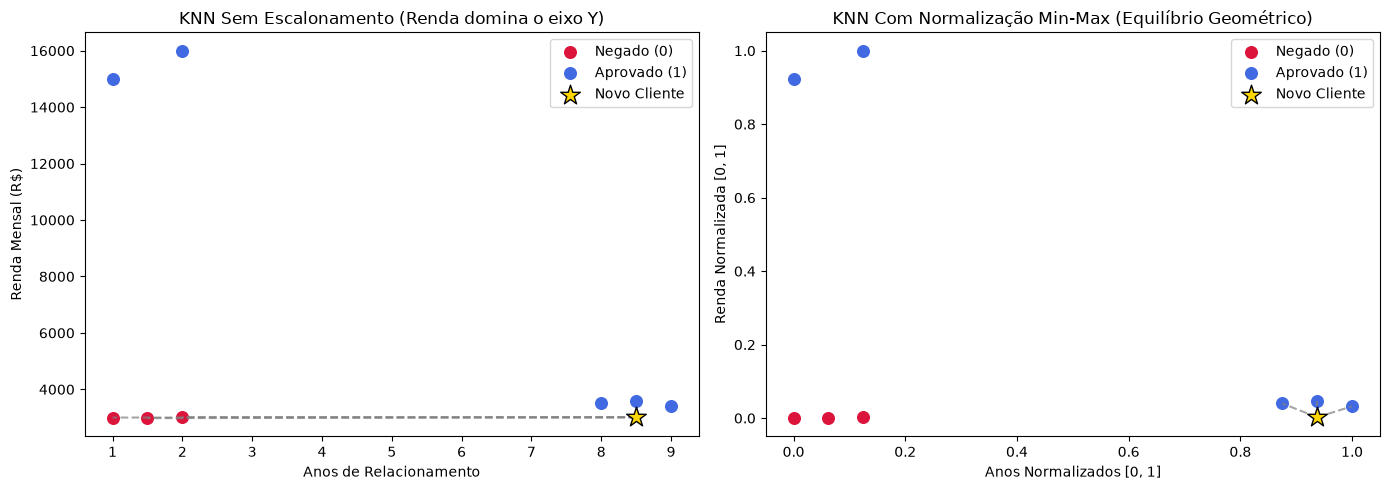

In [33]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Espaço de Características Bruto (Sem Escala)
axes[0].scatter(X_bruto[y == 0, 0], X_bruto[y == 0, 1], color="crimson", s=70, label="Negado (0)")
axes[0].scatter(X_bruto[y == 1, 0], X_bruto[y == 1, 1], color="royalblue", s=70, label="Aprovado (1)")
axes[0].scatter(novo_cliente[0, 0], novo_cliente[0, 1], color="gold", edgecolors="black", marker="*", s=220, label="Novo Cliente", zorder=5)

for idx in indices_sem_escala[0]:
    axes[0].plot([novo_cliente[0, 0], X_bruto[idx, 0]], [novo_cliente[0, 1], X_bruto[idx, 1]], "--", color="gray", alpha=0.7)

axes[0].set_title("KNN Sem Escalonamento (Renda domina o eixo Y)")
axes[0].set_xlabel("Anos de Relacionamento")
axes[0].set_ylabel("Renda Mensal (R$)")
axes[0].legend()

# 2. Espaço de Características Normalizado ([0, 1])
axes[1].scatter(X_minmax[y == 0, 0], X_minmax[y == 0, 1], color="crimson", s=70, label="Negado (0)")
axes[1].scatter(X_minmax[y == 1, 0], X_minmax[y == 1, 1], color="royalblue", s=70, label="Aprovado (1)")
axes[1].scatter(novo_cliente_minmax[0, 0], novo_cliente_minmax[0, 1], color="gold", edgecolors="black", marker="*", s=220, label="Novo Cliente", zorder=5)

for idx in indices_minmax[0]:
    axes[1].plot([novo_cliente_minmax[0, 0], X_minmax[idx, 0]], [novo_cliente_minmax[0, 1], X_minmax[idx, 1]], "--", color="gray", alpha=0.7)

axes[1].set_title("KNN Com Normalização Min-Max (Equilíbrio Geométrico)")
axes[1].set_xlabel("Anos Normalizados [0, 1]")
axes[1].set_ylabel("Renda Normalizada [0, 1]")
axes[1].legend()

plt.tight_layout()
plt.show()

NameError: name 'SimpleImputer' is not defined